<a href="https://colab.research.google.com/github/jai-Lykaios/deep_learning/blob/main/exp1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# SIMPLE CNN FOR MULTI-CLASS IMAGE CLASSIFICATION
# Fashion-MNIST

import tensorflow as tf
from tensorflow.keras import layers, models
import os

# --------------------------------------------------
# 1. Download Fashion-MNIST Dataset
# --------------------------------------------------

url = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/fashion-mnist.npz"

file_path = tf.keras.utils.get_file(
    "fashion-mnist.npz",
    origin=url
)

print("Dataset downloaded successfully!")


# --------------------------------------------------
# 2. Load Dataset
# --------------------------------------------------

import numpy as np

data = np.load(file_path)

x_train = data["x_train"]
y_train = data["y_train"]

x_test = data["x_test"]
y_test = data["y_test"]

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)


# --------------------------------------------------
# 3. Normalize Images
# --------------------------------------------------

x_train = x_train / 255.0
x_test = x_test / 255.0


# --------------------------------------------------
# 4. Reshape Images
# --------------------------------------------------

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


# --------------------------------------------------
# 5. Build CNN Model
# --------------------------------------------------

model = models.Sequential([

    layers.Conv2D(
        32, (3, 3),
        activation='relu',
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation='relu'
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    # Multi-class output
    layers.Dense(
        10,
        activation='softmax'
    )
])


# --------------------------------------------------
# 6. Display Model
# --------------------------------------------------

model.summary()


# --------------------------------------------------
# 7. Compile Model
# --------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# --------------------------------------------------
# 8. Train Model
# --------------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)


# --------------------------------------------------
# 9. Evaluate Model
# --------------------------------------------------

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

Exception: URL fetch failure on https://storage.googleapis.com/tensorflow/tf-keras-datasets/fashion-mnist.npz: 404 -- Not Found

In [ ]:
import zipfile

zip_file = "fashion-mnist.zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content/fashion_mnist")

print("ZIP file extracted successfully!")

FileNotFoundError: [Errno 2] No such file or directory: 'fashion-mnist.zip'

In [ ]:
!wget -O fashion_mnist.zip https://support.sas.com/documentation/prod-p/vdmml/zip/fashion_mnist.zip

print("Dataset downloaded successfully!")

--2026-09-01 05:54:32--  https://support.sas.com/documentation/prod-p/vdmml/zip/fashion_mnist.zip
Resolving support.sas.com (support.sas.com)... 23.12.15.108
Connecting to support.sas.com (support.sas.com)|23.12.15.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45708604 (44M) [application/zip]
Saving to: ‘fashion_mnist.zip’

fashion_mnist.zip   100%[===================>]  43.59M   445KB/s    in 1m 48s  

2026-09-01 05:56:20 (415 KB/s) - ‘fashion_mnist.zip’ saved [45708604/45708604]

Dataset downloaded successfully!


In [ ]:
import zipfile

with zipfile.ZipFile("fashion_mnist.zip", "r") as zip_ref:
    zip_ref.extractall("/content/fashion_mnist")

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
import os

base_dir = "/content/fashion_mnist"

print(os.listdir(base_dir))

['data']


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

train_df = pd.read_csv(os.path.join(base_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(base_dir, "test.csv"))

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))
def load_images(df, image_dir):

    images = []
    labels = []

    for _, row in df.iterrows():

        image_path = os.path.join(
            image_dir,
            str(row["id"]) + ".png"
        )

        image = Image.open(image_path).convert("L")
        images.append(np.array(image))
        labels.append(row["label"])

    return np.array(images), np.array(labels)


x_train, y_train = load_images(train_df, train_dir)
x_test, y_test = load_images(test_df, test_dir)

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(
        32, (3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(
        64, (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model.summary()
model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)
loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


FileNotFoundError: [Errno 2] No such file or directory: '/content/fashion_mnist/train.csv'

In [ ]:
import os

for root, dirs, files in os.walk("/content/fashion_mnist"):
    print("Folder:", root)
    print("Files:", files[:10])

Folder: /content/fashion_mnist
Files: []
Folder: /content/fashion_mnist/data
Files: ['LICENSE', 'metadata_train.csv', 'metadata_test.csv']
Folder: /content/fashion_mnist/data/train
Files: ['9_54390.png', '4_49398.png', '6_27244.png', '7_45872.png', '4_48283.png', '5_28017.png', '2_28579.png', '0_57513.png', '2_34454.png', '6_46050.png']
Folder: /content/fashion_mnist/data/test
Files: ['0_605.png', '6_5952.png', '6_1725.png', '5_4996.png', '2_1475.png', '8_8310.png', '2_1837.png', '3_1335.png', '7_6455.png', '1_8056.png']


In [ ]:
# ============================================================
# PART B: MULTI-CLASS CNN - FASHION MNIST
# ============================================================

import os
import zipfile
import gzip
import struct
import urllib.request
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------------------------
# 1. Download Fashion-MNIST ZIP file
# ------------------------------------------------------------

zip_url = "https://github.com/zalandoresearch/fashion-mnist/archive/refs/heads/master.zip"

zip_file = "/content/fashion-mnist.zip"

urllib.request.urlretrieve(zip_url, zip_file)

print("ZIP file downloaded successfully!")


# ------------------------------------------------------------
# 2. Extract ZIP file
# ------------------------------------------------------------

extract_path = "/content/fashion_mnist"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")


# ------------------------------------------------------------
# 3. Dataset path
# ------------------------------------------------------------

data_dir = os.path.join(
    extract_path,
    "fashion-mnist-master",
    "data",
    "fashion"
)

print("Dataset path:", data_dir)


# ------------------------------------------------------------
# 4. Function to load images
# ------------------------------------------------------------

def load_images(filename):

    with gzip.open(filename, "rb") as f:

        magic, num, rows, cols = struct.unpack(
            ">IIII",
            f.read(16)
        )

        data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

        data = data.reshape(num, rows, cols)

    return data


# ------------------------------------------------------------
# 5. Function to load labels
# ------------------------------------------------------------

def load_labels(filename):

    with gzip.open(filename, "rb") as f:

        magic, num = struct.unpack(
            ">II",
            f.read(8)
        )

        labels = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

    return labels


# ------------------------------------------------------------
# 6. Load training and testing data
# ------------------------------------------------------------

x_train = load_images(
    os.path.join(
        data_dir,
        "train-images-idx3-ubyte.gz"
    )
)

y_train = load_labels(
    os.path.join(
        data_dir,
        "train-labels-idx1-ubyte.gz"
    )
)

x_test = load_images(
    os.path.join(
        data_dir,
        "t10k-images-idx3-ubyte.gz"
    )
)

y_test = load_labels(
    os.path.join(
        data_dir,
        "t10k-labels-idx1-ubyte.gz"
    )
)

print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)


# ------------------------------------------------------------
# 7. Normalize images
# ------------------------------------------------------------

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# ------------------------------------------------------------
# 8. Add channel dimension
# ------------------------------------------------------------

x_train = x_train.reshape(
    -1, 28, 28, 1
)

x_test = x_test.reshape(
    -1, 28, 28, 1
)


# ------------------------------------------------------------
# 9. Build CNN Model
# ------------------------------------------------------------

model = models.Sequential([

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        input


_IncompleteInputError: incomplete input (1356345560.py, line 164)

ZIP file downloaded successfully!
ZIP file extracted successfully!
Dataset files extracted successfully!
Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.6683 - loss: 0.9324 - val_accuracy: 0.7713 - val_loss: 0.6279
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 34ms/step - accuracy: 0.7903 - loss: 0.5655 - val_accuracy: 0.8190 - val_loss: 0.5017
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.8230 - loss: 0.4860 - val_accuracy: 0.8370 - val_loss: 0.4583
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.8419 - loss: 0.4390 - val_accuracy: 0.8381 - val_loss: 0.4466
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 49s 32ms/step - accuracy: 0.8535 - loss: 0.4090 - val_accuracy: 0.8526 - val_loss: 0.4155
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 35ms/step - accuracy: 0.8601 - loss: 0.3850 - val_accuracy: 0.8575 - val_loss: 0.3896
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 34ms/step - accuracy: 0.8672 - loss: 0.3673 - val_accuracy: 0.8664 - val_loss: 0.3676
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 55s 37ms/step - accuracy: 0.8729 -

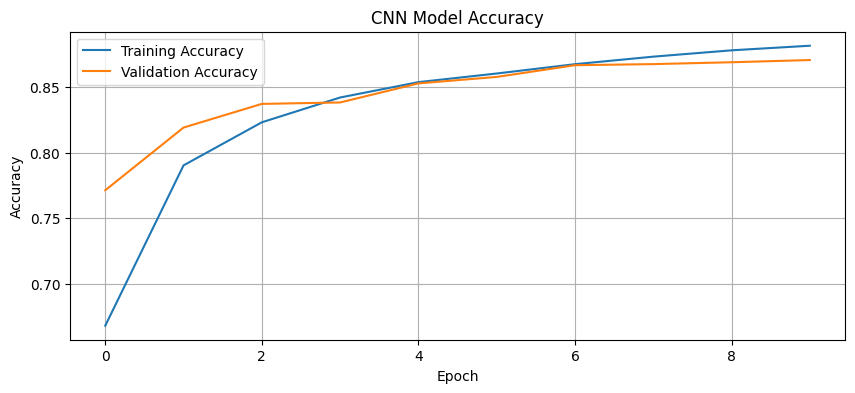

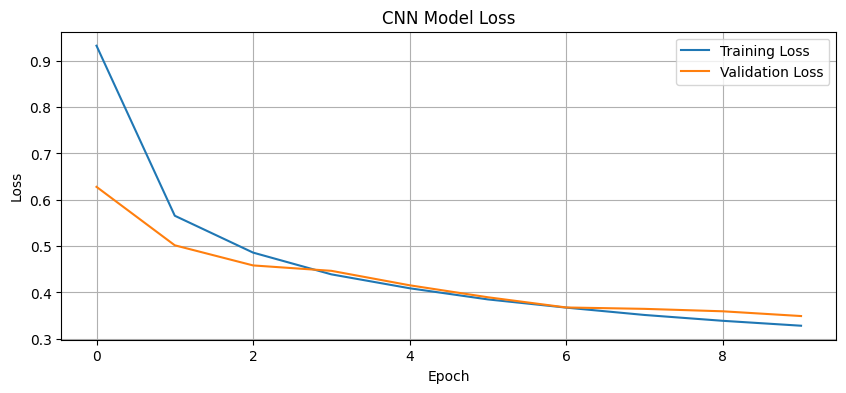

In [ ]:
# ============================================================
# PART B: MULTI-CLASS IMAGE CLASSIFICATION USING CNN
# Fashion-MNIST
# ============================================================

import os
import zipfile
import gzip
import struct
import urllib.request
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

# ------------------------------------------------------------
# 1. Download Fashion-MNIST ZIP file
# ------------------------------------------------------------

zip_url = "https://github.com/zalandoresearch/fashion-mnist/archive/refs/heads/master.zip"
zip_path = "/content/fashion-mnist.zip"

urllib.request.urlretrieve(zip_url, zip_path)

print("ZIP file downloaded successfully!")


# ------------------------------------------------------------
# 2. Extract ZIP file
# ------------------------------------------------------------

extract_path = "/content/fashion_mnist"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP file extracted successfully!")


# ------------------------------------------------------------
# 3. Dataset path
# ------------------------------------------------------------

data_path = "/content/fashion_mnist/fashion-mnist-master/data/fashion"


# ------------------------------------------------------------
# 4. Extract .gz files
# ------------------------------------------------------------

gz_files = [
    "train-images-idx3-ubyte.gz",
    "train-labels-idx1-ubyte.gz",
    "t10k-images-idx3-ubyte.gz",
    "t10k-labels-idx1-ubyte.gz"
]

for file in gz_files:

    gz_path = os.path.join(data_path, file)
    output_path = os.path.join(data_path, file[:-3])

    if not os.path.exists(output_path):
        with gzip.open(gz_path, "rb") as f_in:
            with open(output_path, "wb") as f_out:
                f_out.write(f_in.read())

print("Dataset files extracted successfully!")


# ------------------------------------------------------------
# 5. Load Images
# ------------------------------------------------------------

def load_images(filename):

    with open(filename, "rb") as f:

        magic, num, rows, cols = struct.unpack(
            ">IIII",
            f.read(16)
        )

        data = np.frombuffer(
            f.read(),
            dtype=np.uint8
        )

        return data.reshape(num, rows, cols)


# ------------------------------------------------------------
# 6. Load Labels
# ------------------------------------------------------------

def load_labels(filename):

    with open(filename, "rb") as f:

        magic, num = struct.unpack(
            ">II",
            f.read(8)
        )

        return np.frombuffer(
            f.read(),
            dtype=np.uint8
        )


# ------------------------------------------------------------
# 7. Read Training and Testing Data
# ------------------------------------------------------------

x_train = load_images(
    os.path.join(data_path, "train-images-idx3-ubyte")
)

y_train = load_labels(
    os.path.join(data_path, "train-labels-idx1-ubyte")
)

x_test = load_images(
    os.path.join(data_path, "t10k-images-idx3-ubyte")
)

y_test = load_labels(
    os.path.join(data_path, "t10k-labels-idx1-ubyte")
)

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)


# ------------------------------------------------------------
# 8. Normalize Images
# ------------------------------------------------------------

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0


# ------------------------------------------------------------
# 9. Reshape Images
# ------------------------------------------------------------

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)


# ------------------------------------------------------------
# 10. Build CNN Model
# ------------------------------------------------------------

model = models.Sequential([

    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(
        32,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    layers.MaxPooling2D(
        (2, 2)
    ),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    # 10 classes - Softmax
    layers.Dense(
        10,
        activation="softmax"
    )
])


# ------------------------------------------------------------
# 11. Display Model
# ------------------------------------------------------------

model.summary()


# ------------------------------------------------------------
# 12. Compile Model
# ------------------------------------------------------------

model.compile(
    optimizer=tf.keras.optimizers.SGD(
        learning_rate=0.01
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 13. Train Model
# ------------------------------------------------------------

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)


# ------------------------------------------------------------
# 14. Evaluate Model
# ------------------------------------------------------------

loss, accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(10, 4))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


# Loss Graph
plt.figure(figsize=(10, 4))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()